# Module 04: Seaborn for Machine Learning
## Notebook 01: Seaborn Architecture and Distribution Visualizations

Seaborn is a high-level statistical data visualization library built on top of Matplotlib and integrated tightly with Pandas DataFrames. It automates complex statistical aggregations, error estimation, and multi-dimensional aesthetic mappings with minimal code.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Explain the architectural difference between **Figure-Level** and **Axes-Level** functions.
2. Apply global statistical themes and palettes using `sns.set_theme()`.
3. Visualize univariate continuous distributions with `sns.histplot()` and Kernel Density Estimation (`kde=True`).
4. Generate bivariate density surfaces using `sns.kdeplot()`.
5. Quantify cumulative probability thresholds using `sns.ecdfplot()`.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set consistent, modern styling
sns.set_theme(style="whitegrid", palette="muted")
print(f"Seaborn version: {sns.__version__}")

Seaborn version: 0.13.2


### 1. Figure-Level vs. Axes-Level Architecture

Understanding this distinction avoids 90% of Seaborn layout confusion:
- **Axes-Level Functions** (e.g., `histplot`, `kdeplot`, `scatterplot`, `boxplot`):
  - Draw directly onto an existing Matplotlib `Axes` object.
  - Accept an `ax=...` argument and integrate seamlessly into Matplotlib multi-subplot grids!
- **Figure-Level Functions** (e.g., `displot`, `relplot`, `catplot`):
  - Control their own whole `Figure` (instantiating a `FacetGrid`).
  - Cannot be passed an existing `ax` argument directly.

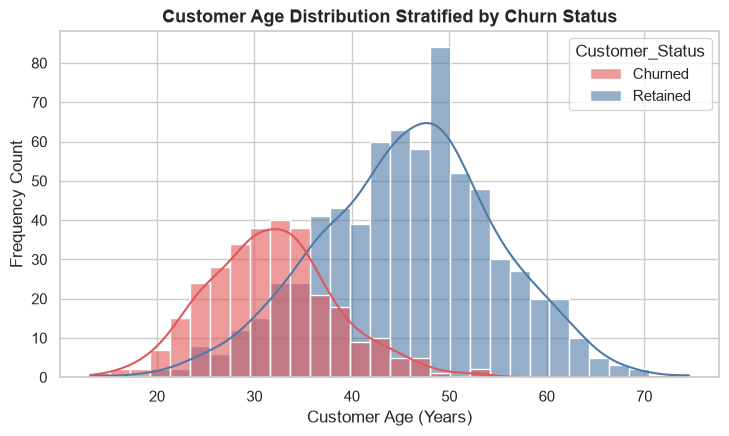

In [2]:
# Generate synthetic classification dataset: Two customer age distributions
rng = np.random.default_rng(42)
ages_churned = rng.normal(loc=32, scale=7, size=300)
ages_retained = rng.normal(loc=46, scale=9, size=700)

df = pd.DataFrame({
    'Age': np.concatenate([ages_churned, ages_retained]),
    'Customer_Status': ['Churned'] * len(ages_churned) + ['Retained'] * len(ages_retained)
})

# Axes-level integration with Matplotlib
fig, ax = plt.subplots(figsize=(8.5, 4.5))

sns.histplot(
    data=df, 
    x='Age', 
    hue='Customer_Status', 
    kde=True, 
    bins=30, 
    palette={'Churned': '#E15759', 'Retained': '#4E79A7'},
    alpha=0.6,
    ax=ax
)

ax.set_title("Customer Age Distribution Stratified by Churn Status", fontsize=13, fontweight='bold')
ax.set_xlabel("Customer Age (Years)")
ax.set_ylabel("Frequency Count")

plt.show()

---
### 2. Kernel Density Estimation (KDE) and Bivariate Surfaces

KDE estimates the continuous Probability Density Function (PDF) of a random variable without assuming a parametric form (like Gaussian).
Bivariate KDE reveals multi-modal clusters and non-linear joint interactions.

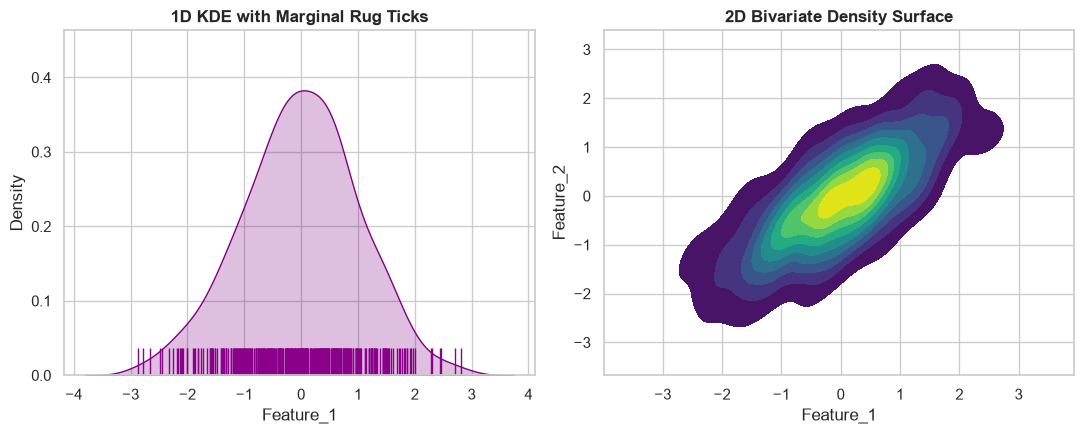

In [3]:
# Generate 2 continuous features
x_feat = rng.normal(0, 1, 400)
y_feat = x_feat * 0.7 + rng.normal(0, 0.6, 400)
df_bi = pd.DataFrame({'Feature_1': x_feat, 'Feature_2': y_feat})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# 1D KDE with rug plot
sns.kdeplot(data=df_bi, x='Feature_1', fill=True, color='purple', ax=ax1)
sns.rugplot(data=df_bi, x='Feature_1', color='darkmagenta', height=0.08, ax=ax1)
ax1.set_title("1D KDE with Marginal Rug Ticks", fontweight='bold')

# 2D Bivariate density contours
sns.kdeplot(data=df_bi, x='Feature_1', y='Feature_2', cmap='viridis', fill=True, thresh=0.05, ax=ax2)
ax2.set_title("2D Bivariate Density Surface", fontweight='bold')

plt.tight_layout()
plt.show()

---
### 3. Empirical Cumulative Distribution Functions: `sns.ecdfplot()`

While histograms depend heavily on arbitrary bin width choices, the **ECDF** has zero hyperparameters and displays the exact proportion of observations falling below any threshold value:
$$F_n(x) = \frac{1}{n} \sum_{i=1}^n \mathbb{I}(x_i \le x)$$

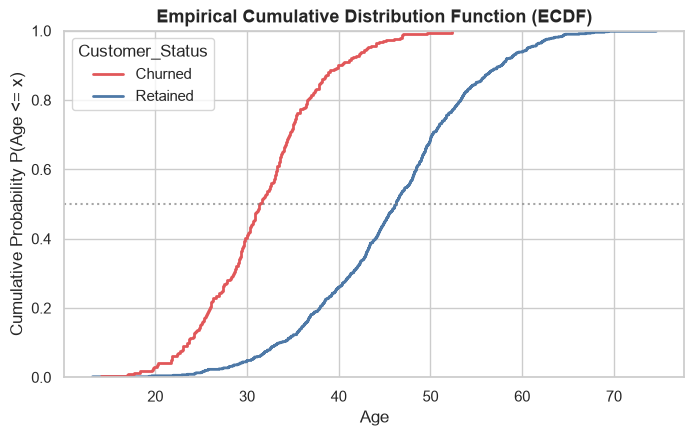

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))

sns.ecdfplot(data=df, x='Age', hue='Customer_Status', palette={'Churned': '#E15759', 'Retained': '#4E79A7'}, linewidth=2, ax=ax)

ax.set_title("Empirical Cumulative Distribution Function (ECDF)", fontsize=13, fontweight='bold')
ax.set_xlabel("Age")
ax.set_ylabel("Cumulative Probability P(Age <= x)")
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.7)

plt.show()

### Summary & Next Steps
In this notebook, you mastered:
- Figure-Level vs. Axes-Level architecture.
- Univariate and bivariate continuous density estimation.
- ECDF analysis for threshold probability calculation.

**Next Notebook:** `02_relational_and_categorical_plots.ipynb` — Scatterplots with hue/style/size, boxplots, violinplots, and statistical barplots.